In [2]:
!pip install -q -U transformers accelerate bitsandbytes peft trl datasets
!pip install -q pillow huggingface_hub

In [ ]:
from huggingface_hub import login
login()

In [2]:
import os
import random
from PIL import Image
from datasets import Dataset
 
DATASET_PATH = "/workspace/cattle-dataset/Cows datasets"
 
# Folder names must match your dataset structure (foot-and-mouth / lumpy / healthy)
disease_info = {
    "foot-and-mouth": {
        "name": "Foot-and-Mouth Disease",
        "confidence_pool": ["High", "Medium"],
        "image_evidence": (
            "visible vesicles (fluid-filled blisters) and erosions around the mouth, "
            "tongue, gums, and/or the coronary band of the feet"
        ),
        "symptom_pool": [
            "fever", "blisters or sores on the mouth and feet", "excessive salivation",
            "lameness or limping", "loss of appetite", "reluctance to move or stand",
        ],
        "why_text": (
            "Foot-and-Mouth Disease (FMD) is a highly contagious viral disease of "
            "cloven-hoofed animals, spread through direct contact, contaminated "
            "equipment, and airborne transmission. It is a notifiable disease under "
            "international (WOAH) reporting standards, meaning any suspected case "
            "must be reported to veterinary authorities without delay."
        ),
        "rule_out": (
            "Vesicular stomatitis and other blistering conditions can resemble FMD, "
            "and lameness alone can also stem from foot rot or injury — a veterinarian "
            "should confirm the diagnosis."
        ),
        "actions": [
            "Isolate this animal from the rest of your herd immediately",
            "Do NOT move the animal off your farm",
            "Contact the Ghana Veterinary Service or your nearest vet right away",
            "Disinfect all areas, tools, and equipment the animal has contacted",
            "Do not sell milk or meat from this animal until cleared by a vet",
            "Report the case — FMD is a notifiable disease under WOAH reporting standards",
        ],
    },
    "lumpy": {
        "name": "Lumpy Skin Disease",
        "confidence_pool": ["High", "Medium"],
        "image_evidence": (
            "multiple firm, raised skin nodules, most often concentrated around the "
            "head, neck, and limbs, consistent with Lumpy Skin Disease lesions"
        ),
        "symptom_pool": [
            "firm nodules or lumps on the skin", "high fever", "swollen lymph nodes",
            "reduced milk production", "weight loss", "watery eyes or nasal discharge",
        ],
        "why_text": (
            "Lumpy Skin Disease (LSD) is a poxvirus infection spread mainly by "
            "biting insects such as flies, mosquitoes, and ticks. It has been present "
            "in West Africa, including Ghana, for decades and is recognized as a "
            "notifiable disease by the World Organisation for Animal Health (WOAH) "
            "due to its potential for rapid spread and economic impact."
        ),
        "rule_out": (
            "Insect bite reactions, ringworm, and other skin conditions can look "
            "similar in early stages — a vet should confirm via examination or lab test."
        ),
        "actions": [
            "Isolate the affected animal from the rest of your herd immediately",
            "Vaccinate healthy cattle in your herd as prevention",
            "Contact your veterinarian for treatment and confirmation options",
            "Keep the animal in a shaded area away from biting insects",
            "Do not sell or move this animal off your farm",
            "Spray insecticide around the farm to reduce insect vectors",
        ],
    },
    "healthy": {
        "name": "Healthy",
        "confidence_pool": ["High", "Medium"],
        "image_evidence": (
            "no visible blisters, nodules, or skin lesions; the coat, mouth, and feet "
            "appear normal"
        ),
        "symptom_pool": [
            "normal appetite", "active and alert behavior", "smooth clean skin",
            "clear bright eyes", "normal breathing rate",
        ],
        "why_text": (
            "None of the described signs match the typical presentation of FMD "
            "(vesicles/blisters) or LSD (skin nodules). The animal appears to be in "
            "good general health based on the information provided."
        ),
        "rule_out": (
            "Subtle or early-stage disease can be hard to catch from a single "
            "observation — continue routine monitoring, and note that unexplained "
            "weight loss alone can also indicate parasites or nutritional deficiency "
            "rather than a notifiable disease, and is worth a vet check if it persists."
        ),
        "actions": [
            "Continue regular health monitoring of your herd",
            "Maintain good hygiene and sanitation on your farm",
            "Ensure the animal has access to clean water and balanced feed",
            "Keep vaccination schedules up to date",
            "Schedule regular veterinary checkups",
            "Monitor for any changes in behavior, appetite, or appearance",
        ],
    },
}
 
# --- System prompts: MUST match app.py exactly so training and inference align ---
SYSTEM_PROMPT_IMAGE = """You are an expert veterinary AI specialized in 
Ghanaian cattle disease detection. Analyze the cattle image 
carefully and provide an accurate disease diagnosis with 
practical recommendations for smallholder farmers.
Always structure your response with:
1. Disease name
2. Confidence level (High/Medium/Low)
3. Key symptoms visible in the image
4. Recommended actions numbered clearly"""
 
SYSTEM_PROMPT_SYMPTOMS = """You are an expert veterinary AI specialized in 
Ghanaian cattle disease detection. Based on the symptoms 
described by the farmer, provide an accurate disease diagnosis 
and practical recommendations.
Always structure your response with:
1. Most likely disease name
2. Confidence level (High/Medium/Low)
3. Why these symptoms suggest this disease
4. Recommended actions numbered clearly
5. Other possible diseases to rule out"""
 
SYSTEM_PROMPT_BOTH = """You are an expert veterinary AI specialized in 
Ghanaian cattle disease detection. You have been provided with 
BOTH an image of the cattle AND a description of symptoms from 
the farmer. Use both pieces of information together to give the 
most accurate diagnosis possible.
Always structure your response with:
1. Disease name
2. Confidence level (High/Medium/Low)
3. Evidence from image
4. Evidence from symptoms described
5. Recommended actions numbered clearly"""
 
USER_PROMPT_IMAGE = "What disease does this cattle have? Provide diagnosis and recommendations for the farmer."
 
 
def sample_symptoms(key, n=None):
    pool = disease_info[key]["symptom_pool"]
    n = n or random.randint(2, min(4, len(pool)))
    return random.sample(pool, n)
 
 
def format_actions(actions):
    return "\n".join(f"{i+1}. {a}" for i, a in enumerate(actions))
 
 
def build_image_response(key):
    info = disease_info[key]
    confidence = random.choice(info["confidence_pool"])
    return (
        f"1. Disease name: {info['name']}\n"
        f"2. Confidence level: {confidence}\n"
        f"3. Key symptoms visible in the image: {info['image_evidence']}.\n"
        f"4. Recommended actions:\n{format_actions(info['actions'])}"
    )
 
 
def build_symptom_response(key, symptoms):
    info = disease_info[key]
    confidence = random.choice(info["confidence_pool"])
    symptom_str = ", ".join(symptoms)
    return (
        f"1. Most likely disease name: {info['name']}\n"
        f"2. Confidence level: {confidence}\n"
        f"3. Why these symptoms suggest this disease: The reported {symptom_str} "
        f"are consistent with {info['name']}. {info['why_text']}\n"
        f"4. Recommended actions:\n{format_actions(info['actions'])}\n"
        f"5. Other possible diseases to rule out: {info['rule_out']}"
    )
 
 
def build_combined_response(key, symptoms):
    info = disease_info[key]
    confidence = random.choice(info["confidence_pool"])
    symptom_str = ", ".join(symptoms)
    return (
        f"1. Disease name: {info['name']}\n"
        f"2. Confidence level: {confidence}\n"
        f"3. Evidence from image: {info['image_evidence']}.\n"
        f"4. Evidence from symptoms described: The farmer reports {symptom_str}, "
        f"which aligns with {info['name']}.\n"
        f"5. Recommended actions:\n{format_actions(info['actions'])}"
    )
 
 
def build_image_records(dataset_path, max_per_class=300):
    records = []
    for key in disease_info:
        folder = os.path.join(dataset_path, key)
        if not os.path.exists(folder):
            print(f"Warning: {folder} not found")
            continue
        images = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
        random.shuffle(images)
        images = images[:max_per_class]
        print(f"{key}: {len(images)} images")
        for img in images:
            records.append({"image_path": os.path.join(folder, img), "disease_key": key})
    random.shuffle(records)
    return records
 
 
image_records = build_image_records(DATASET_PATH, max_per_class=300)
split = int(len(image_records) * 0.9)
train_image_records, val_image_records = image_records[:split], image_records[split:]
print(f"\nImage records — Train: {len(train_image_records)} | Val: {len(val_image_records)}")

foot-and-mouth: 300 images
lumpy: 300 images
healthy: 300 images

Image records — Train: 810 | Val: 90


In [18]:
import os
print("Top-level /workspace contents:")
for item in os.listdir("/workspace"):
    print(" ", item)

Top-level /workspace contents:
  gemma3-cattle-merged
  training_curve.png
  gemma3-cattle-finetuned-final
  gemma3-cattle-finetuned
  .cache
  Cows datasets.zip
  .ipynb_checkpoints
  Untitled.ipynb


In [19]:
!unzip -o "/workspace/Cows datasets.zip" -d /workspace/cattle-dataset

Archive:  /workspace/Cows datasets.zip
   creating: /workspace/cattle-dataset/Cows datasets/
   creating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/
  inflating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/-1-_jpg.rf.6d3e8fb103569503844b178ef99c9b16.jpg  
  inflating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/-10-_jpg.rf.41fcfc66abb914e0e35794d81ad6c11a.jpg  
  inflating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/-11-_jpg.rf.c0738d766686485afec6f2ce4e104526.jpg  
  inflating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/-12-_jpg.rf.35780a7e0b23f958085cf41bb08ae5ee.jpg  
  inflating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/-13-_jpg.rf.d0856413cfecd933cf5d87410de09e3a.jpg  
  inflating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/-14-_jpg.rf.a010c87f02f9edb905ec50d2f10e96f6.jpg  
  inflating: /workspace/cattle-dataset/Cows datasets/foot-and-mouth/-15-_jpg.rf.7bd97d4dd140f2fd0149627463ee132b.jpg  
  infl

In [3]:
TEXT_EXAMPLES_PER_CLASS = 120   # symptoms-only synthetic examples per disease class
COMBINED_EXAMPLES_PER_IMAGE = 1  # how many symptom variants to pair with each image
 
 
def to_image_example(record):
    image = Image.open(record["image_path"]).convert("RGB").resize((512, 512))
    key = record["disease_key"]
    return {
        "images": [image],
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT_IMAGE}]},
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": USER_PROMPT_IMAGE},
            ]},
            {"role": "assistant", "content": [{"type": "text", "text": build_image_response(key)}]},
        ],
    }
 
 
def to_symptom_example(key):
    symptoms = sample_symptoms(key)
    symptoms_text = ", ".join(symptoms)
    user_text = f"My cattle is showing these symptoms: {symptoms_text}. What disease could this be and what should I do?"
    return {
        "images": [],
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT_SYMPTOMS}]},
            {"role": "user", "content": [{"type": "text", "text": user_text}]},
            {"role": "assistant", "content": [{"type": "text", "text": build_symptom_response(key, symptoms)}]},
        ],
    }
 
 
def to_combined_example(record):
    key = record["disease_key"]
    image = Image.open(record["image_path"]).convert("RGB").resize((512, 512))
    symptoms = sample_symptoms(key)
    symptoms_text = ", ".join(symptoms)
    user_text = (
        f"The farmer reports these symptoms: {symptoms_text}. Based on both the "
        f"image and these symptoms, what disease does this cattle have and what "
        f"should the farmer do?"
    )
    return {
        "images": [image],
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT_BOTH}]},
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": user_text},
            ]},
            {"role": "assistant", "content": [{"type": "text", "text": build_combined_response(key, symptoms)}]},
        ],
    }
 
 
def build_split(image_records):
    examples = []
    # Mode 1: image only
    examples += [to_image_example(r) for r in image_records]
    # Mode 3: image + symptoms (reuse the same images with sampled symptom text)
    for r in image_records:
        for _ in range(COMBINED_EXAMPLES_PER_IMAGE):
            examples.append(to_combined_example(r))
    return examples
 
 
print("Building image-based examples (modes 1 and 3)...")
train_examples = build_split(train_image_records)
val_examples = build_split(val_image_records)
 
print("Building text-only symptom examples (mode 2)...")
for key in disease_info:
    n_train = int(TEXT_EXAMPLES_PER_CLASS * 0.9)
    n_val = TEXT_EXAMPLES_PER_CLASS - n_train
    train_examples += [to_symptom_example(key) for _ in range(n_train)]
    val_examples += [to_symptom_example(key) for _ in range(n_val)]
 
random.shuffle(train_examples)
random.shuffle(val_examples)
 
print(f"\nFinal dataset — Train: {len(train_examples)} | Val: {len(val_examples)}")
 
train_dataset = Dataset.from_list(train_examples)
val_dataset = Dataset.from_list(val_examples)

Building image-based examples (modes 1 and 3)...
Building text-only symptom examples (mode 2)...

Final dataset — Train: 1944 | Val: 216


In [6]:
import torch
from transformers import AutoProcessor, BitsAndBytesConfig, Gemma3ForConditionalGeneration
 
MODEL_ID = "google/gemma-3-4b-it"
 
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
 
print("Loading processor...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
 
print("Loading Gemma 3 4B Vision model...")
model = Gemma3ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    attn_implementation="eager",
)
model.config.use_cache = False
 
free, total = (x / 1024**3 for x in torch.cuda.mem_get_info())
print(f"GPU: {free:.1f}GB free / {total:.1f}GB total")

Loading processor...
Loading Gemma 3 4B Vision model...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

GPU: 88.3GB free / 95.0GB total


In [8]:
from peft import LoraConfig
 
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
    bias="none",
)

In [9]:
def collate_fn(examples):
    texts = [
        processor.apply_chat_template(ex["messages"], tokenize=False, add_generation_prompt=False)
        for ex in examples
    ]
    images = [ex["images"] for ex in examples]  # empty list [] for text-only examples
 
    # Gemma3's processor checks `if images is not None` to decide whether to run
    # its image pipeline. A list of all-empty per-example sublists (e.g. [[], []])
    # is NOT None, so it still tries to process images and crashes on an empty
    # nested structure. If this whole batch has zero images anywhere, pass the
    # literal None instead so the image pipeline is skipped entirely.
    has_any_image = any(len(im) > 0 for im in images)
 
    batch = processor(
        text=texts,
        images=images if has_any_image else None,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024,
    )
 
    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    if hasattr(processor, "image_token_id"):
        labels[labels == processor.image_token_id] = -100
    batch["labels"] = labels
    return batch

In [10]:
import shutil
shutil.rmtree("/workspace/gemma3-cattle-finetuned", ignore_errors=True)
shutil.rmtree("/workspace/gemma3-cattle-finetuned-final", ignore_errors=True)

In [11]:
from trl import SFTTrainer, SFTConfig
 
training_args = SFTConfig(
    output_dir="/workspace/gemma3-cattle-finetuned",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    warmup_steps=50,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    remove_unused_columns=False,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",
    dataloader_pin_memory=False,
    dataset_kwargs={"skip_prepare_dataset": True},  # we handle formatting ourselves
)
 
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    peft_config=lora_config,
    data_collator=collate_fn,
)
 
print("Starting training...")
trainer.train()
print("Training complete!")
 
trainer.save_model("/workspace/gemma3-cattle-finetuned-final")
processor.save_pretrained("/workspace/gemma3-cattle-finetuned-final")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Starting training...


[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.023266,0.023103,0.023372,997427.000000,0.987321
2,0.023570,0.022096,0.022092,1994854.000000,0.987061
3,0.020122,0.021946,0.021242,2992281.000000,0.987843


Training complete!


['/workspace/gemma3-cattle-finetuned-final/processor_config.json']

In [14]:
!pip install -q matplotlib

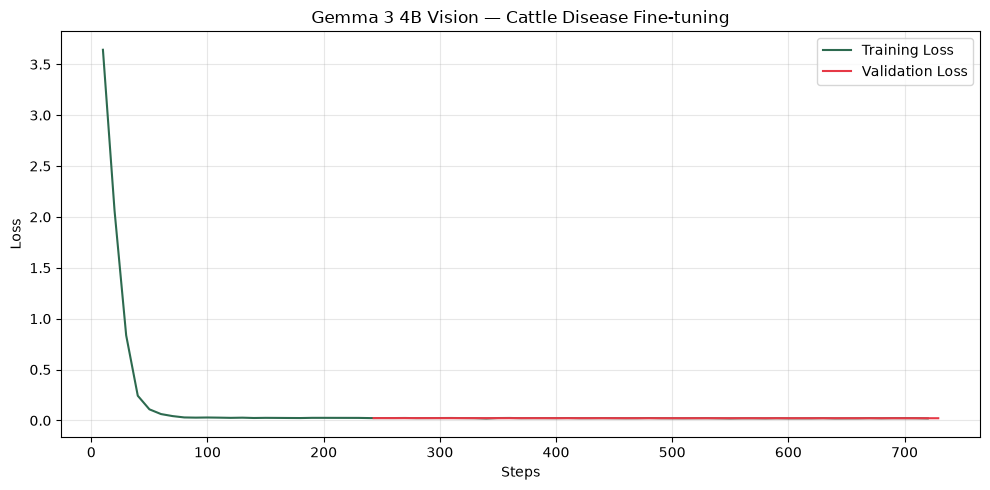

In [12]:
import matplotlib.pyplot as plt
 
history = trainer.state.log_history
train_loss = [h["loss"] for h in history if "loss" in h and "eval_loss" not in h]
eval_loss = [h["eval_loss"] for h in history if "eval_loss" in h]
train_steps = [h["step"] for h in history if "loss" in h and "eval_loss" not in h]
eval_steps = [h["step"] for h in history if "eval_loss" in h]
 
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Training Loss", color="#2D6A4F")
plt.plot(eval_steps, eval_loss, label="Validation Loss", color="#E63946")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Gemma 3 4B Vision — Cattle Disease Fine-tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/workspace/training_curve.png", dpi=150)
plt.show()

In [16]:
for key in disease_info:
    class_images = [r for r in val_image_records if r["disease_key"] == key]
    if class_images:
        print(f"\n=== TRUE CLASS: {key} ===")
        print(diagnose_image(class_images[0]["image_path"], merged_model))
    else:
        print(f"\n=== TRUE CLASS: {key} === (no val images for this class!)")


=== TRUE CLASS: foot-and-mouth ===
1. Disease name: Foot-and-Mouth Disease
2. Confidence level: High
3. Key symptoms visible in the image: visible vesicles (fluid-filled blisters) and erosions around the mouth, tongue, gums, and/or the coronary band of the feet.
4. Recommended actions:
1. Isolate this animal from the rest of your herd immediately
2. Do NOT move the animal off your farm
3. Contact the Ghana Veterinary Service or your nearest vet right away
4. Disinfect all areas, tools, and equipment the animal has contacted
5. Do not sell milk or meat from this animal until cleared by a vet
6. Report the case — FMD is a notifiable disease under WOAH reporting standards

=== TRUE CLASS: lumpy ===
1. Disease name: Lumpy Skin Disease
2. Confidence level: High
3. Key symptoms visible in the image: multiple firm, raised skin nodules, most often concentrated around the head, neck, and limbs, consistent with Lumpy Skin Disease lesions.
4. Recommended actions:
1. Isolate the affected animal f

In [14]:
from peft import PeftModel
 
HF_USERNAME = "Bakari17"
REPO_NAME = "gemma3-cattle-disease-ghana"   # <-- change this if you like
REPO_ID = f"{HF_USERNAME}/{REPO_NAME}"
 
print("Reloading base model in bf16 (not 4-bit) for a clean merge...")
base_model_fp = Gemma3ForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto",
)
merged_model = PeftModel.from_pretrained(base_model_fp, "/workspace/gemma3-cattle-finetuned-final")
merged_model = merged_model.merge_and_unload()
 
merged_model.save_pretrained("/workspace/gemma3-cattle-merged", safe_serialization=True)
processor.save_pretrained("/workspace/gemma3-cattle-merged")
 
print(f"Pushing merged model to https://huggingface.co/{REPO_ID} ...")
merged_model.push_to_hub(REPO_ID, safe_serialization=True)
processor.push_to_hub(REPO_ID)
 
print(f"\n✅ Done! Model live at: https://huggingface.co/{REPO_ID}")
print(f"Add to your .env: GEMMA_MODEL_NAME={REPO_ID}")

Reloading base model in bf16 (not 4-bit) for a clean merge...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing merged model to https://huggingface.co/Bakari17/gemma3-cattle-disease-ghana ...


TypeError: PushToHubMixin.push_to_hub() got an unexpected keyword argument 'safe_serialization'

In [20]:
def diagnose_image(image_path, model_to_use):
    image = Image.open(image_path).convert("RGB")
    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT_IMAGE}]},
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": USER_PROMPT_IMAGE}]},
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=text, images=[image], return_tensors="pt").to(model_to_use.device)
    with torch.no_grad():
        output = model_to_use.generate(**inputs, max_new_tokens=350)
    new_tokens = output[0][inputs["input_ids"].shape[1]:]
    return processor.decode(new_tokens, skip_special_tokens=True)

In [21]:
def diagnose_symptoms(symptoms_text, model_to_use):
    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT_SYMPTOMS}]},
        {"role": "user", "content": [{"type": "text", "text": f"My cattle is showing these symptoms: {symptoms_text}. What disease could this be and what should I do?"}]},
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=text, images=None, return_tensors="pt").to(model_to_use.device)  # <-- None, not []
    with torch.no_grad():
        output = model_to_use.generate(**inputs, max_new_tokens=350)
    new_tokens = output[0][inputs["input_ids"].shape[1]:]
    return processor.decode(new_tokens, skip_special_tokens=True)

In [22]:
print(diagnose_symptoms("nodules on the neck, high fever, not eating much", merged_model))

1. Most likely disease name: Lumpy Skin Disease
2. Confidence level: High
3. Why these symptoms suggest this disease: The reported nodules on the neck, high fever, not eating much are consistent with Lumpy Skin Disease. Lumpy Skin Disease (LSD) is a poxvirus infection spread mainly by biting insects such as flies, mosquitoes, and ticks. It has been present in West Africa, including Ghana, for decades and is recognized as a notifiable disease by the World Organisation for Animal Health (WOAH). The symptoms align with the known presentation of LSD.
4. Recommended actions:
1. Isolate the affected animal from the rest of your herd immediately
2. Vaccinate healthy cattle in your herd as prevention
3. Contact your veterinarian for treatment and confirmation options
4. Keep the animal in a shaded area away from biting insects
5. Do not sell or move this animal off your farm
6. Spray insecticide around the farm to reduce insect vectors
5. Other possible diseases to rule out: Insect bite reacti

In [23]:
merged_model.push_to_hub(REPO_ID)
processor.push_to_hub(REPO_ID)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Bakari17/gemma3-cattle-disease-ghana/commit/7dcfc82d99810931896277f516bc826bb4e54274', commit_message='Upload processor', commit_description='', oid='7dcfc82d99810931896277f516bc826bb4e54274', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Bakari17/gemma3-cattle-disease-ghana', endpoint='https://huggingface.co', repo_type='model', repo_id='Bakari17/gemma3-cattle-disease-ghana'), pr_revision=None, pr_num=None)